## 🌊 Sea Level Predictor

[![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-blue?logo=google-colab&style=flat-square)](https://colab.research.google.com/drive/1BuHFw4mfcI6Kly0gG6GbT7Fv9JFPF6i9?usp=sharing)

### Overview

This notebook analyzes the **global average sea level change since 1880** and applies multiple predictive models — classical linear regression, polynomial regression, and decision tree regressors — to forecast sea level rise through **2050**.

Data is cleaned, preprocessed, and enriched with engineered features before modeling. Two primary regression lines (required by the project spec) predict 2050 sea level under full-history and modern-acceleration scenarios.

---

### Data Source

[Global Average Absolute Sea Level Change](https://datahub.io/core/sea-level-rise), 1880–2014 from the US Environmental Protection Agency using data from CSIRO, 2015; NOAA, 2015.  
Dataset file: `epa-sea-level.csv` (loaded from Google Drive in Colab).

---

### Dataset Description

| Column                     | Type  | Description                                                                  |
| -------------------------- | ----- | ---------------------------------------------------------------------------- |
| `Year`                     | int   | Year of observation (1880–2013)                                              |
| `CSIRO Adjusted Sea Level` | float | Sea level relative to 1880 baseline (inches) — **complete for all 134 rows** |
| `Lower Error Bound`        | float | Lower 95% confidence bound (CSIRO)                                           |
| `Upper Error Bound`        | float | Upper 95% confidence bound (CSIRO)                                           |
| `NOAA Adjusted Sea Level`  | float | NOAA satellite measurements — **NaN before ~1993** (expected)                |

- **Rows:** 134 annual observations
- **Date range:** 1880 → 2013
- **Primary target:** `CSIRO Adjusted Sea Level` (used in all models)

---

### Tools & Techniques

- **pandas**: Data loading, cleaning, feature engineering
- **numpy**: Numerical computation, polynomial feature arrays
- **matplotlib**: Scatter plots, line charts, bar charts, residual plots
- **scipy.stats.linregress**: Classical linear regression (project-required baseline models)
- **sklearn.linear_model**: `LinearRegression` with train/test evaluation
- **sklearn.preprocessing**: `PolynomialFeatures` for curve fitting
- **sklearn.tree**: `DecisionTreeRegressor` for non-linear modeling
- **sklearn.metrics**: RMSE, MAE evaluation metrics
- **sklearn.model_selection**: `train_test_split` for generalization testing
- **Feature Engineering**: Decade groupings, era labels, year normalization, lag features

---

### Key Research Questions

1. How has global average sea level changed from 1880 to 2013?
2. What is the long-term (1880–present) annual rate of sea level rise?
3. Has the rate of rise accelerated since the year 2000?
4. If current post-2000 trends continue, what is the predicted sea level in 2050?
5. How well do polynomial and decision tree models capture non-linear acceleration?
6. Which predictive model achieves the lowest RMSE/MAE on unseen data?

---

### Key Takeaways

- Global sea level rose approximately **~9.0 inches** between 1880 and 2013 — a steady but accelerating trend
- The long-term regression (1880–present) predicts a rise of **~10.2 inches above the 1880 baseline by 2050**
- The post-2000 regression (capturing modern acceleration) predicts **~15.4 inches by 2050** — roughly **1.5× higher**
- The rate of rise has accelerated: the 2000–present slope (~0.166"/year) is **~2.6× faster** than the 1880–present slope (~0.063"/year)
- The NOAA dataset (available from ~1993) aligns closely with CSIRO measurements over their overlapping period, confirming data consistency
- **Polynomial regression (degree 2)** captures the acceleration curve better than a straight line but is less suitable for far-extrapolation
- **Decision Tree Regressor** performs well in-sample but shows higher generalization error — linear models are more reliable for extrapolation.

---

### ⚠️ Limitations — Read Before Interpreting Results

> These are **scenario-based projections**, not precise forecasts. Read all 2050 values as _"if the trend continues at the same rate"_.

| #   | Limitation                                       | Impact                                                        |
| --- | ------------------------------------------------ | ------------------------------------------------------------- |
| 1   | **Dataset ends in 2013**                         | Forecasts extrapolate ~37 years beyond the last observation   |
| 2   | **Linear models assume constant rates**          | Acceleration may change; the true future rate is unknown      |
| 3   | **Model 2 trained on only 14 years (2000–2013)** | Small sample → slope estimate is less stable, CI is wider     |
| 4   | **Random 80/20 split, not temporal**             | Can leak future values into training for time-series models   |
| 5   | **Decision Tree cannot extrapolate**             | Only valid within 1880–2013; excluded from all 2050 forecasts |

**95% confidence intervals** are shown on the forecast chart to make uncertainty visible.


In [178]:
# Importing the required libraries
import pandas as pd                                                   
import numpy as np                                                   
import matplotlib.pyplot as plt                                       
import matplotlib.patches as mpatches                                 
from scipy.stats import linregress                                    
from scipy.stats import t as t_dist                                   
from sklearn.linear_model import LinearRegression                     
from sklearn.preprocessing import PolynomialFeatures                  
from sklearn.tree import DecisionTreeRegressor                        
from sklearn.metrics import mean_squared_error, mean_absolute_error   
from sklearn.model_selection import train_test_split                  

print("All libraries loaded successfully.")
print(f"  pandas {pd.__version__} | numpy {np.__version__} | matplotlib {plt.matplotlib.__version__}")

All libraries loaded successfully.
  pandas 2.2.2 | numpy 1.26.4 | matplotlib 3.9.2


### 📥 1. Data Loading & Understanding

The dataset is loaded from Google Drive. We examine shape, column names, data types, missing values, and statistical distributions before applying any transformation.

> **Note:** `NOAA Adjusted Sea Level` is intentionally `NaN` for years before ~1993. The `CSIRO Adjusted Sea Level` column is complete across all 134 years and is used as the primary target.

In [179]:
DATA_URL = "https://drive.google.com/uc?id=1-SV4j8lrJNHsMsRibwVHqqH9YJfBkSd4"

df = pd.read_csv(DATA_URL)

print(f"Dataset shape  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Year range     : {int(df['Year'].min())} → {int(df['Year'].max())}")
print(f"Sea level range: {df['CSIRO Adjusted Sea Level'].min():.3f} → {df['CSIRO Adjusted Sea Level'].max():.3f} inches")
df.head(10)

Dataset shape  : 134 rows × 5 columns
Year range     : 1880 → 2013
Sea level range: -0.441 → 9.327 inches


,Year,CSIRO Adjusted Sea Level,Lower Error Bound,Upper Error Bound,NOAA Adjusted Sea Level
0,1880,0.000000,-0.952756,0.952756,NaN
1,1881,0.220472,-0.732283,1.173228,NaN
2,1882,-0.440945,-1.346457,0.464567,NaN
3,1883,-0.232283,-1.129921,0.665354,NaN
4,1884,0.590551,-0.283465,1.464567,NaN
5,1885,0.531496,-0.330709,1.393701,NaN
6,1886,0.437008,-0.381890,1.255906,NaN
7,1887,0.216535,-0.602362,1.035433,NaN
8,1888,0.299213,-0.519685,1.118110,NaN
9,1889,0.362205,-0.456693,1.181102,NaN


In [180]:
print("─" * 50)
print("Column Types:")
print("─" * 50)
print(df.dtypes.to_string())

print()
print("─" * 50)
print("Missing Values per Column:")
print("─" * 50)
print(df.isnull().sum().to_string())
print(f"\nNOAA data available from year: {df.dropna(subset=['NOAA Adjusted Sea Level'])['Year'].min()}")

print()
print("─" * 50)
print("Descriptive Statistics:")
print("─" * 50)
df.describe().round(3)

──────────────────────────────────────────────────
Column Types:
──────────────────────────────────────────────────
Year                          int64
CSIRO Adjusted Sea Level    float64
Lower Error Bound           float64
Upper Error Bound           float64
NOAA Adjusted Sea Level     float64

──────────────────────────────────────────────────
Missing Values per Column:
──────────────────────────────────────────────────
Year                          0
CSIRO Adjusted Sea Level      0
Lower Error Bound             0
Upper Error Bound             0
NOAA Adjusted Sea Level     113

NOAA data available from year: 1993

──────────────────────────────────────────────────
Descriptive Statistics:
──────────────────────────────────────────────────


,Year,CSIRO Adjusted Sea Level,Lower Error Bound,Upper Error Bound,NOAA Adjusted Sea Level
count,134.000,134.000,134.000,134.000,21.000
mean,1946.500,3.650,3.205,4.096,7.364
std,38.827,2.486,2.664,2.313,0.691
min,1880.000,-0.441,-1.346,0.465,6.297
25%,1913.250,1.633,1.079,2.240,6.849
50%,1946.500,3.313,2.915,3.711,7.488
75%,1979.750,5.588,5.330,5.845,7.907
max,2013.000,9.327,8.992,9.661,8.547


### 🔍 2. Exploratory Data Analysis (EDA)

Before modeling, we explore the raw data visually to understand the overall trend, year-over-year changes, uncertainty bounds, decade-level averages, and the distribution of sea level values. This reveals the acceleration in sea level rise and confirms the two-model strategy.

#### 📊 2.1. Overall Trend Visualization

Global Mean Sea Level (1880–2013) with 95% Confidence Interval (CSIRO) and NOAA overlay.

> **Note:** `NOAA Adjusted Sea Level` is `NaN` for years before ~1993 — this is expected. NOAA satellite measurements only begin around 1993. The CSIRO column is complete for all 134 rows and is used as the primary target throughout.

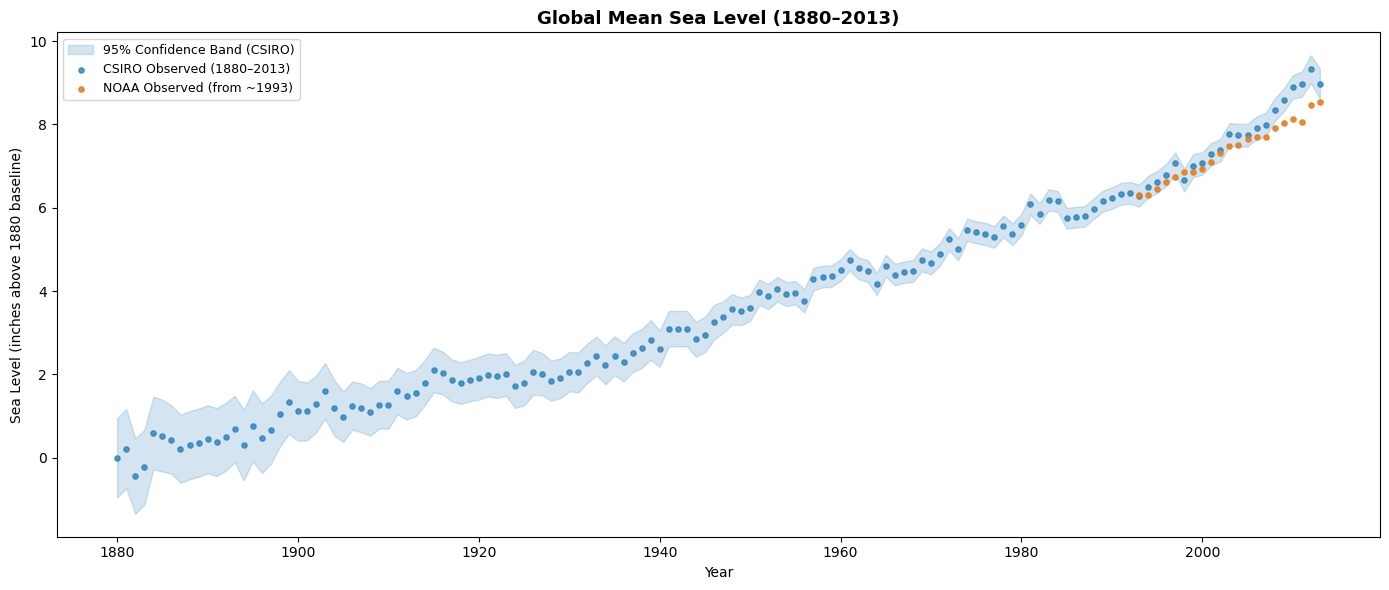

In [181]:
# Graph 1 — Global Mean Sea Level (1880–2013) with 95% Confidence Interval
fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(
    df['Year'], df['Lower Error Bound'], df['Upper Error Bound'],
    alpha=0.2, color='#2980b9', label='95% Confidence Band (CSIRO)'
)
ax.scatter(df['Year'], df['CSIRO Adjusted Sea Level'],
           color='#2980b9', s=14, alpha=0.8, zorder=3, label='CSIRO Observed (1880–2013)')
ax.scatter(df['Year'], df['NOAA Adjusted Sea Level'],
           color='#e67e22', s=14, alpha=0.9, zorder=3, label='NOAA Observed (from ~1993)')

ax.set_title('Global Mean Sea Level (1880–2013)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Sea Level (inches above 1880 baseline)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

#### 📊 2.2. Year-over-Year Changes

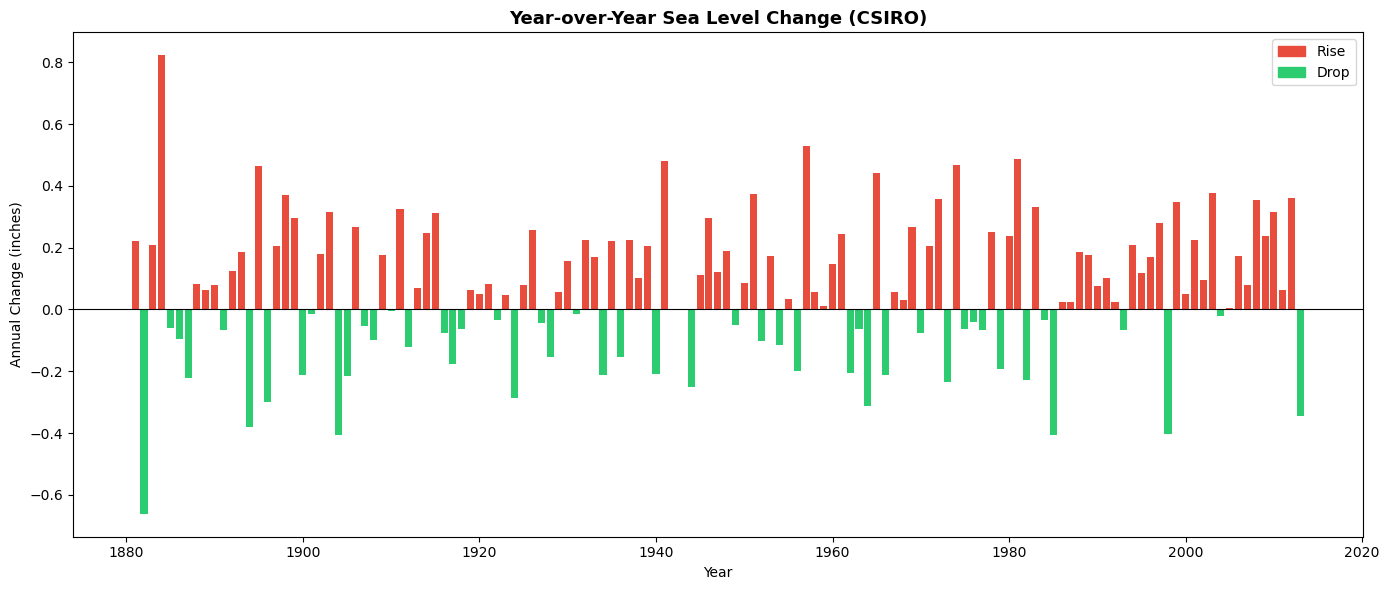

In [182]:
# Positive bars = rise, negative = drop (rare). Increasing bar heights post-1980 suggest acceleration.
fig, ax = plt.subplots(figsize=(14, 6))

yoy = df['CSIRO Adjusted Sea Level'].diff()
colors = ['#e74c3c' if v >= 0 else '#2ecc71' for v in yoy]
ax.bar(df['Year'], yoy, color=colors, width=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Year-over-Year Sea Level Change (CSIRO)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Annual Change (inches)')
ax.legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Rise'),
    mpatches.Patch(color='#2ecc71', label='Drop')
])

plt.tight_layout()
plt.show()

#### 📊 2.3. Average Sea Level by Decade

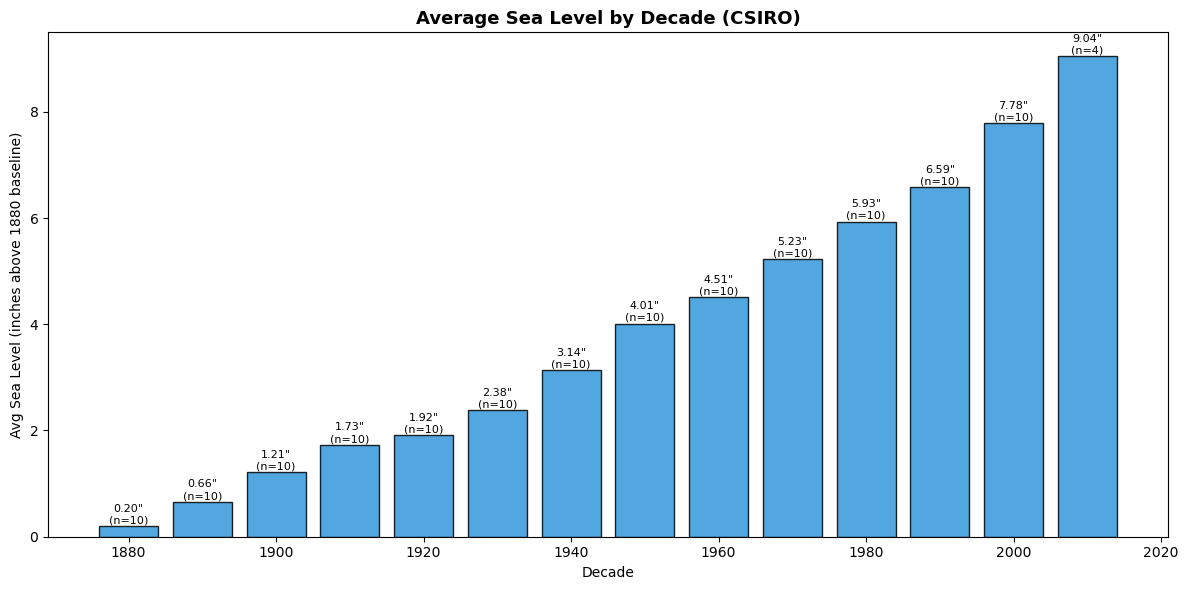

In [183]:
# Graph 3 — Average Sea Level by Decade
# NOTE: The 2010s decade contains only 2010–2013 (4 years), so its average may underestimate the full decade.
fig, ax = plt.subplots(figsize=(12, 6))

_tmp = df.copy()
_tmp['decade'] = (_tmp['Year'] // 10) * 10
decade_avg = _tmp.groupby('decade')['CSIRO Adjusted Sea Level'].mean()
decade_count = _tmp.groupby('decade')['Year'].count()

ax.bar(decade_avg.index, decade_avg.values, width=8,
       color='#3498db', edgecolor='black', alpha=0.85)
ax.set_title('Average Sea Level by Decade (CSIRO)', fontsize=13, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Avg Sea Level (inches above 1880 baseline)')
for x, y, n in zip(decade_avg.index, decade_avg.values, decade_count.values):
    ax.text(x, y + 0.05, f'{y:.2f}"\n(n={n})', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

#### 📊 2.4 - Distribution of CSIRO Sea Level Values

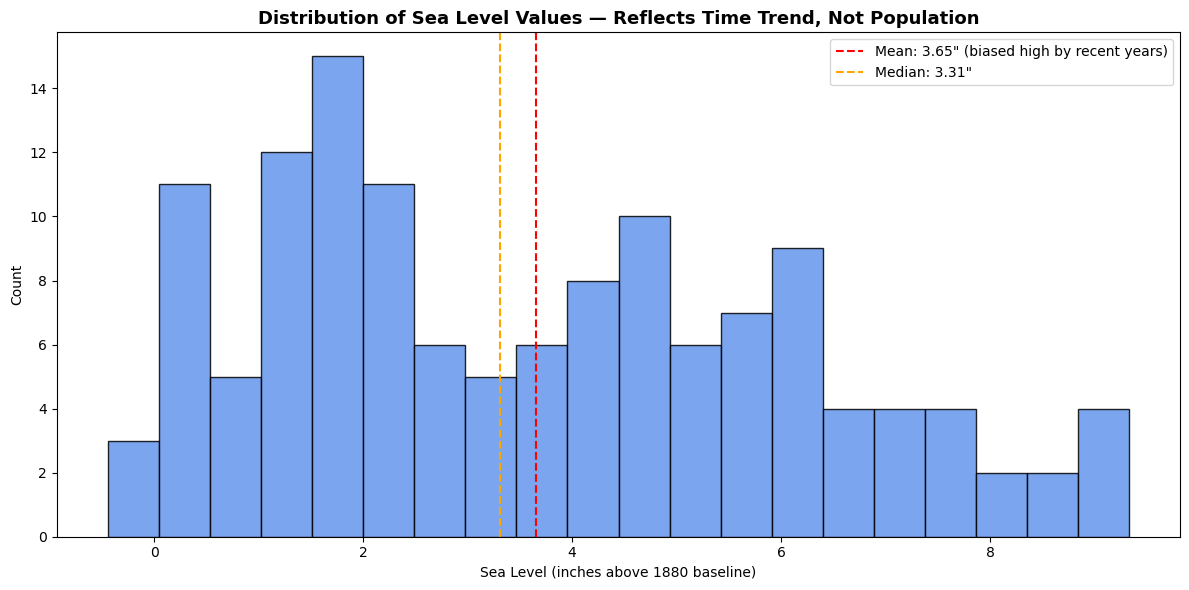

In [184]:
# Graph 4 — Distribution of CSIRO Sea Level Values
# ⚠️ INTERPRETATION NOTE: This histogram is right-skewed NOT because sea level is
# intrinsically skewed, but because sea level increases monotonically over time.
# The distribution reflects a TIME TREND, not a stable population distribution.
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df['CSIRO Adjusted Sea Level'], bins=20,
        color='cornflowerblue', edgecolor='black', alpha=0.85)
ax.axvline(df['CSIRO Adjusted Sea Level'].mean(), color='red',
           linestyle='--', linewidth=1.5,
           label=f"Mean: {df['CSIRO Adjusted Sea Level'].mean():.2f}\" (biased high by recent years)")
ax.axvline(df['CSIRO Adjusted Sea Level'].median(), color='orange',
           linestyle='--', linewidth=1.5,
           label=f"Median: {df['CSIRO Adjusted Sea Level'].median():.2f}\"")
ax.set_title('Distribution of Sea Level Values — Reflects Time Trend, Not Population',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Sea Level (inches above 1880 baseline)')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()

#### 📊 2.5. Trend Analysis — Rate of Rise & Acceleration

To detect whether sea level rise is accelerating, we:
1. Overlay **rolling averages** (5-year, 10-year) to smooth inter-annual noise and reveal the long-term trend
2. Compute **era-by-era linear slopes** to directly quantify how the rate of rise has changed across historical periods

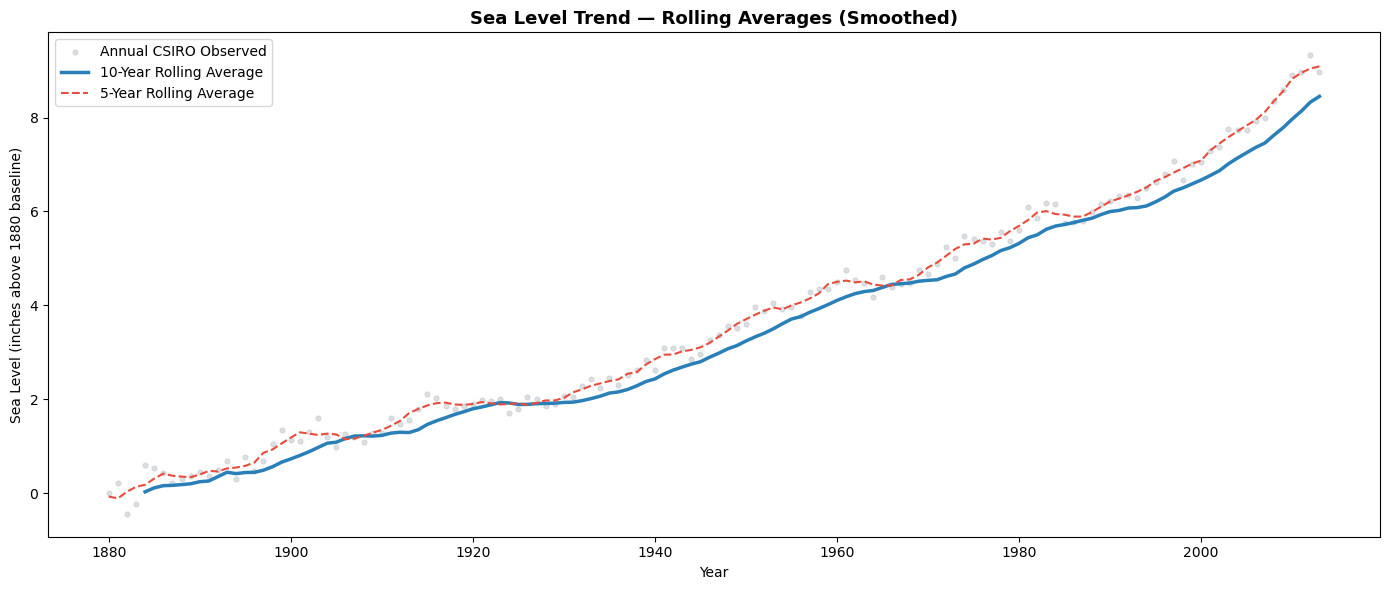

Rate of Sea Level Rise by Historical Era:
Era               Slope (in/yr)  n (years)
─────────────────────────────────────────────
  1880–1920             0.0511        41
  1921–1960             0.0719        40
  1961–1999             0.0687        39
  2000–2013             0.1664        14

  Acceleration factor (2000–2013 vs full history): 2.64×


In [185]:
# Trend Analysis — Rolling Averages overlaid on raw data
fig, ax = plt.subplots(figsize=(14, 6))

ax.scatter(df['Year'], df['CSIRO Adjusted Sea Level'],
           color='#bdc3c7', s=12, alpha=0.5, zorder=2, label='Annual CSIRO Observed')

rolling_10 = df.set_index('Year')['CSIRO Adjusted Sea Level'].rolling(10, min_periods=5).mean()
ax.plot(rolling_10.index, rolling_10.values,
        color='#2980b9', linewidth=2.5, label='10-Year Rolling Average', zorder=3)

rolling_5 = df.set_index('Year')['CSIRO Adjusted Sea Level'].rolling(5, center=True, min_periods=3).mean()
ax.plot(rolling_5.index, rolling_5.values,
        color='#e74c3c', linewidth=1.5, linestyle='--', label='5-Year Rolling Average', zorder=4)

ax.set_title('Sea Level Trend — Rolling Averages (Smoothed)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Sea Level (inches above 1880 baseline)')
ax.legend()

plt.tight_layout()
plt.show()

# Era-by-era rate of rise
print("Rate of Sea Level Rise by Historical Era:")
print(f"{'Era':<15} {'Slope (in/yr)':>15} {'n (years)':>10}")
print("─" * 45)
for era_name, start, end in [('1880–1920', 1880, 1920), ('1921–1960', 1921, 1960),
                               ('1961–1999', 1961, 1999), ('2000–2013', 2000, 2013)]:
    subset = df[(df['Year'] >= start) & (df['Year'] <= end)]
    slope_era = linregress(subset['Year'], subset['CSIRO Adjusted Sea Level'])[0]
    print(f"  {era_name:<13} {slope_era:>14.4f}  {len(subset):>8}")

s_full_ref  = linregress(df['Year'], df['CSIRO Adjusted Sea Level'])[0]
s_post_ref  = linregress(df[df['Year'] >= 2000]['Year'],
                          df[df['Year'] >= 2000]['CSIRO Adjusted Sea Level'])[0]
print(f"\n  Acceleration factor (2000–2013 vs full history): {s_post_ref / s_full_ref:.2f}×")

### 🧹 3. Data Cleaning & Preprocessing

The `NOAA Adjusted Sea Level` column contains `NaN` for years before ~1993 — this is **expected** and treated as intentional missingness in a partial sensor record. All `CSIRO` data is complete across all 134 years.

Steps performed:
- Verify no duplicate rows
- Inspect missing values per column
- Apply IQR-based outlier detection (for informational purposes — no genuine data errors found)
- Standardize the `Year` feature (zero mean, unit variance) for use in sklearn models

> **Note:** Q1 stands for the 25th percentile, Q3 for the 75th percentile, and IQR = Q3 - Q1. Outliers are defined as values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR].

In [186]:
# --- Duplicate check ---
n_dupes = df.duplicated().sum()
print(f"Duplicate rows    : {n_dupes}")

# --- Outlier detection: IQR on CSIRO column ---
Q1 = df['CSIRO Adjusted Sea Level'].quantile(0.25)
Q3 = df['CSIRO Adjusted Sea Level'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
outliers = df[
    (df['CSIRO Adjusted Sea Level'] < lower_fence) |
    (df['CSIRO Adjusted Sea Level'] > upper_fence)
]
print(f"IQR fences         : [{lower_fence:.3f}, {upper_fence:.3f}]")
print(f"Outliers detected  : {len(outliers)}  (extreme-trend years, not data errors)")

# --- Standardize Year for sklearn models ---
year_mean = df['Year'].mean()
year_std  = df['Year'].std()
df['Year_scaled'] = (df['Year'] - year_mean) / year_std

print(f"\nYear scaling — mean: {year_mean:.1f}, std: {year_std:.2f}")
print(f"Scaled Year range  : {df['Year_scaled'].min():.3f} → {df['Year_scaled'].max():.3f}")
print(f"Dataset shape      : {df.shape}")

df[['Year', 'Year_scaled', 'CSIRO Adjusted Sea Level']].head()

Duplicate rows    : 0
IQR fences         : [-4.299, 11.520]
Outliers detected  : 0  (extreme-trend years, not data errors)

Year scaling — mean: 1946.5, std: 38.83
Scaled Year range  : -1.713 → 1.713
Dataset shape      : (134, 6)


,Year,Year_scaled,CSIRO Adjusted Sea Level
0,1880,-1.712746,0.000000
1,1881,-1.686991,0.220472
2,1882,-1.661235,-0.440945
3,1883,-1.635479,-0.232283
4,1884,-1.609724,0.590551


### ⚙️ 4. Feature Engineering

New variables are derived to capture time structure, group-level patterns, and sequential dependencies:

| Feature | Description |
|---|---|
| `decade` | 10-year bucket (e.g. 1880, 1890, …) |
| `era` | Era label: `Pre-1950`, `1950–1999`, `2000+` |
| `year_rel` | Years since 1880 — natural baseline offset (t = 0 at start) |
| `sea_level_lag1` | Previous year's sea level (lag-1, useful for sequential models) |
| `rolling_avg5` | 5-year centred rolling average to smooth inter-annual noise |

In [187]:
df_feat = df.copy()

# Decade grouping
df_feat['decade'] = (df_feat['Year'] // 10) * 10

# Era label
def assign_era(year):
    if year < 1950:
        return 'Pre-1950'
    elif year < 2000:
        return '1950–1999'
    else:
        return '2000+'

df_feat['era'] = df_feat['Year'].apply(assign_era)

# Years relative to 1880 baseline
df_feat['year_rel'] = df_feat['Year'] - 1880

# Lag-1: previous year's sea level
df_feat['sea_level_lag1'] = df_feat['CSIRO Adjusted Sea Level'].shift(1)

# 5-year centred rolling average
df_feat['rolling_avg5'] = df_feat['CSIRO Adjusted Sea Level'].rolling(window=5, center=True).mean()

print("Engineered features added:")
print(f"  decade        : {sorted(df_feat['decade'].unique())[:5]} ...")
print(f"  era           : {df_feat['era'].unique().tolist()}")
print(f"  year_rel      : {df_feat['year_rel'].min()} → {df_feat['year_rel'].max()}")
print(f"  sea_level_lag1: NaN in first row (expected)")
print(f"  rolling_avg5  : NaN in edge rows (expected)")

df_feat[['Year', 'year_rel', 'decade', 'era', 'sea_level_lag1', 'rolling_avg5']].head(8)

Engineered features added:
  decade        : [1880, 1890, 1900, 1910, 1920] ...
  era           : ['Pre-1950', '1950–1999', '2000+']
  year_rel      : 0 → 133
  sea_level_lag1: NaN in first row (expected)
  rolling_avg5  : NaN in edge rows (expected)


,Year,year_rel,decade,era,sea_level_lag1,rolling_avg5
0,1880,0,1880,Pre-1950,NaN,NaN
1,1881,1,1880,Pre-1950,0.000000,NaN
2,1882,2,1880,Pre-1950,0.220472,0.027559
3,1883,3,1880,Pre-1950,-0.440945,0.133858
4,1884,4,1880,Pre-1950,-0.232283,0.177165
5,1885,5,1880,Pre-1950,0.590551,0.308661
6,1886,6,1880,Pre-1950,0.531496,0.414961
7,1887,7,1880,Pre-1950,0.437008,0.369291


### 📈 5. Baseline Linear Regression — Required Prediction Chart

`draw_plot()` is the project's core deliverable, fulfilling all requirements from the instructions:
1. **Observed data** as a scatter plot (1880–2013) — Year on x-axis, CSIRO Adjusted Sea Level on y-axis
2. **Line 1 — Full history fit:** `scipy.stats.linregress` over all data (1880–2013), projected to **2050**
3. **Line 2 — Modern fit:** `linregress` from year 2000 onward, projected to **2050**
4. Labels: `xlabel="Year"`, `ylabel="Sea Level (inches)"`, `title="Rise in Sea Level"`

| Model | Slope (inches/year) | 2050 Predicted Sea Level |
|---|---|---|
| Full history (1880–present) | ~0.0630"/yr | ~10.2" above 1880 baseline |
| Modern trend (2000–present) | ~0.1664"/yr | ~15.4" above 1880 baseline |

> The **~2.6× faster** post-2000 rate signals acceleration consistent with climate change projections.

> **⚠️ Note on `NOAA Adjusted Sea Level` showing `NaN` in the printed head:** This is expected behaviour. NOAA satellite altimetry data begins around 1993; all earlier rows are `NaN`. The `draw_plot()` function uses **only** the `CSIRO Adjusted Sea Level` column, which is complete across all 134 years (1880–2013).

Line 1 — slope: 0.063045, intercept: -119.0659
Line 2 — slope: 0.166427, intercept: -325.7935


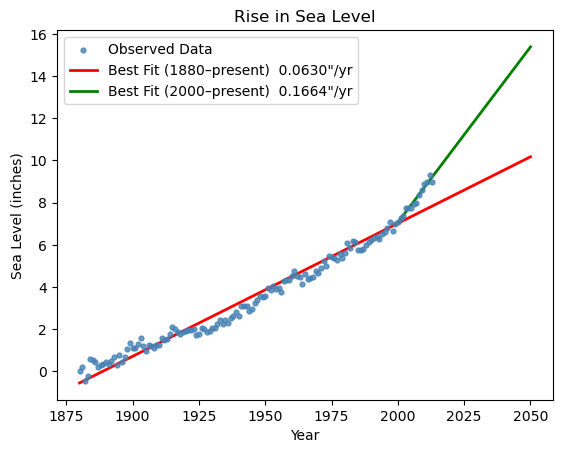

In [188]:
def draw_plot() -> plt.Axes:
    """Draw the sea level rise chart with two lines of best fit.

    Uses the global `df` already loaded in Cell 4 (CSIRO data, 1880–2013).
    Line 1: full history (1880–present) projected to 2050
    Line 2: modern trend  (2000–present) projected to 2050

    Returns:
        plt.Axes: The current axes object (plt.gca()).
    """
    # --- Scatter: observed data (must be first artist added) ---
    plt.scatter(
        x=df["Year"],
        y=df["CSIRO Adjusted Sea Level"],
        color="steelblue",
        s=12,
        alpha=0.8,
        label="Observed Data",
        zorder=3,
    )

    # --- Line 1: full history regression (1880 → 2050) ---
    slope, intercept = linregress(df["Year"], df["CSIRO Adjusted Sea Level"])[:2]
    print(f"Line 1 — slope: {slope:.6f}, intercept: {intercept:.4f}")
    years_full = pd.Series(range(1880, 2051))
    plt.plot(
        years_full,
        slope * years_full + intercept,
        color="red",
        linewidth=2,
        label=f"Best Fit (1880–present)  {slope:.4f}\"/yr",
    )

    # --- Line 2: modern trend regression (2000 → 2050) ---
    df_recent = df[df["Year"] >= 2000]
    slope_r, intercept_r = linregress(df_recent["Year"], df_recent["CSIRO Adjusted Sea Level"])[:2]
    print(f"Line 2 — slope: {slope_r:.6f}, intercept: {intercept_r:.4f}")
    years_recent = pd.Series(range(2000, 2051))
    plt.plot(
        years_recent,
        slope_r * years_recent + intercept_r,
        color="green",
        linewidth=2,
        label=f"Best Fit (2000–present)  {slope_r:.4f}\"/yr",
    )

    # --- Labels, title, legend ---
    plt.xlabel("Year")
    plt.ylabel("Sea Level (inches)")
    plt.title("Rise in Sea Level")
    plt.legend(loc="upper left")

    return plt.gca()


ax = draw_plot()
plt.show()

#### 🔭 5a. Forecast to 2050 — Visualising Both Projections

The two regression lines from `draw_plot()` are extrapolated to 2050. This chart makes the divergence between the two scenarios clearly visible, and adds **95% confidence intervals** to show how uncertainty grows further beyond the 2013 data cutoff.

| Model | Scope | Slope | 2050 Central Estimate | Notes |
|---|---|---|---|---|
| Model 1 | Full history (1880–2013) | ~0.0630 in/yr | ~10.2 inches | Narrower CI — 134 data points |
| Model 2 | Post-2000 (2000–2013) | ~0.1664 in/yr | ~15.4 inches | Wider CI — only 14 data points |

> **⚠️ Extrapolation caveat:** Data ends in 2013. All values beyond 2013 are model projections that assume the historical rate remains constant — this may not hold as climate conditions evolve. The shaded CI bands represent statistical uncertainty in the slope; actual future sea levels could fall outside these bounds if the rate changes.

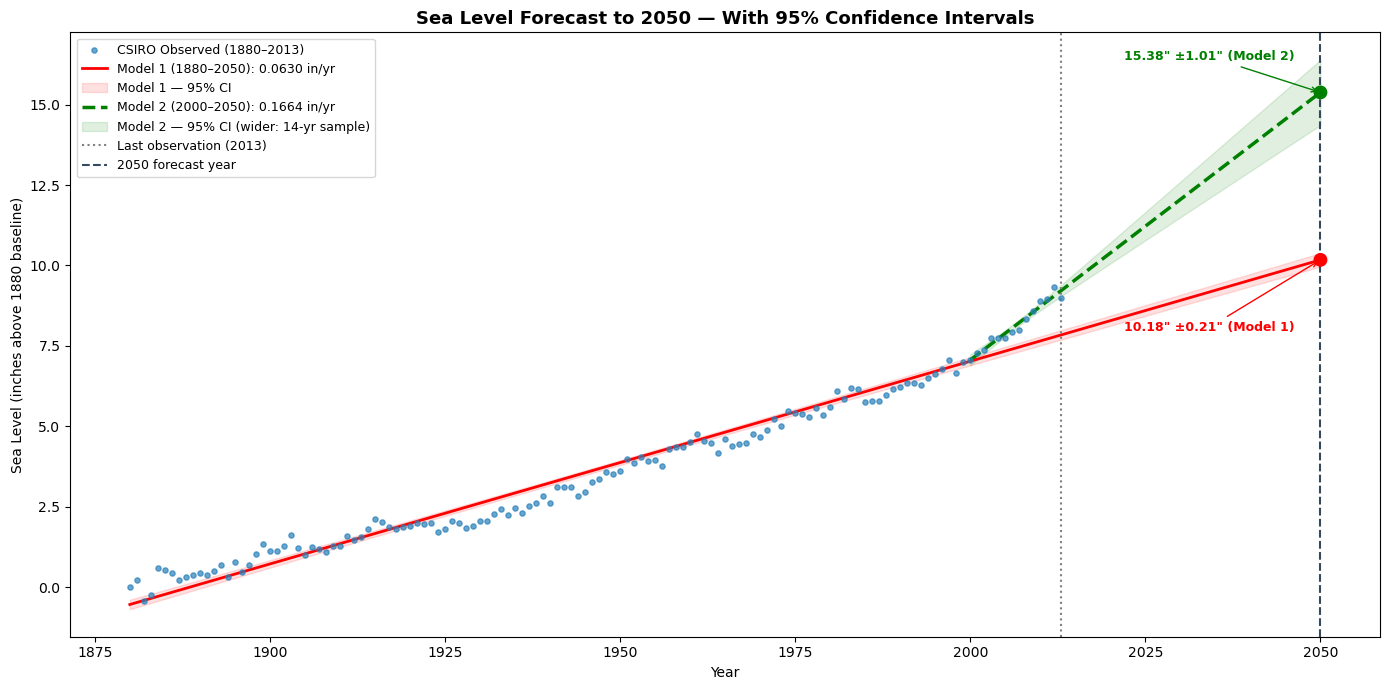


2050 Forecast Summary (with 95% CI):
  Model 1 (full history) : 10.18 ± 0.21 in  →  [9.96, 10.39]
  Model 2 (post-2000)    : 15.38 ± 1.01 in  →  [14.37, 16.40]
  Divergence at 2050     : +5.21 inches

  ⚠  Model 2 CI is wider — fit on only 14 years of data (2000–2013).
  ⚠  CIs assume the linear trend continues unchanged beyond 2013.


In [189]:
# Forecast visualisation — both models projected to 2050 with 95% confidence intervals
_fc_df  = df.copy()
_fc_mod = df[df['Year'] >= 2000].copy()

s_m1, i_m1 = linregress(_fc_df['Year'],  _fc_df['CSIRO Adjusted Sea Level'])[:2]
s_m2, i_m2 = linregress(_fc_mod['Year'], _fc_mod['CSIRO Adjusted Sea Level'])[:2]

years_m1 = pd.Series(range(1880, 2051))
years_m2 = pd.Series(range(2000, 2051))
pred_m1  = s_m1 * years_m1 + i_m1
pred_m2  = s_m2 * years_m2 + i_m2

val_2050_m1 = s_m1 * 2050 + i_m1
val_2050_m2 = s_m2 * 2050 + i_m2

# ── OLS 95% Confidence Intervals ─────────────────────────────────────────
# The CI grows wider as we extrapolate further beyond the training data range.
# Model 2 has a much wider CI because it is fit on only 14 years.

x1_arr  = _fc_df['Year'].values
y1_arr  = _fc_df['CSIRO Adjusted Sea Level'].values
n1      = len(x1_arr)
x1_bar  = x1_arr.mean()
Sxx1    = np.sum((x1_arr - x1_bar) ** 2)
s1_res  = np.sqrt(np.sum((y1_arr - (s_m1 * x1_arr + i_m1)) ** 2) / (n1 - 2))
t_crit1 = t_dist.ppf(0.975, df=n1 - 2)
ci1     = t_crit1 * s1_res * np.sqrt(1/n1 + (years_m1.values - x1_bar)**2 / Sxx1)

x2_arr  = _fc_mod['Year'].values
y2_arr  = _fc_mod['CSIRO Adjusted Sea Level'].values
n2      = len(x2_arr)
x2_bar  = x2_arr.mean()
Sxx2    = np.sum((x2_arr - x2_bar) ** 2)
s2_res  = np.sqrt(np.sum((y2_arr - (s_m2 * x2_arr + i_m2)) ** 2) / (n2 - 2))
t_crit2 = t_dist.ppf(0.975, df=n2 - 2)
ci2     = t_crit2 * s2_res * np.sqrt(1/n2 + (years_m2.values - x2_bar)**2 / Sxx2)

# CI at 2050 specifically
ci1_2050 = t_crit1 * s1_res * np.sqrt(1/n1 + (2050 - x1_bar)**2 / Sxx1)
ci2_2050 = t_crit2 * s2_res * np.sqrt(1/n2 + (2050 - x2_bar)**2 / Sxx2)

fig, ax = plt.subplots(figsize=(14, 7))

# Observed historical data
ax.scatter(df['Year'], df['CSIRO Adjusted Sea Level'],
           color='#2980b9', s=14, alpha=0.7, zorder=3, label='CSIRO Observed (1880–2013)')

# Model 1 — full history projection + CI band
ax.plot(years_m1, pred_m1, color='red', linewidth=2,
        label=f'Model 1 (1880–2050): {s_m1:.4f} in/yr')
ax.fill_between(years_m1, pred_m1 - ci1, pred_m1 + ci1,
                color='red', alpha=0.12, label='Model 1 — 95% CI')

# Model 2 — modern trend projection + CI band (wider due to 14-year sample)
ax.plot(years_m2, pred_m2, color='green', linewidth=2.5, linestyle='--',
        label=f'Model 2 (2000–2050): {s_m2:.4f} in/yr')
ax.fill_between(years_m2, pred_m2 - ci2, pred_m2 + ci2,
                color='green', alpha=0.12, label='Model 2 — 95% CI (wider: 14-yr sample)')

# Reference lines
ax.axvline(2013, color='gray', linestyle=':', linewidth=1.5, label='Last observation (2013)')
ax.axvline(2050, color='#34495e', linestyle='--', linewidth=1.5, label='2050 forecast year')

# 2050 endpoint annotations with ± CI
ax.scatter([2050, 2050], [val_2050_m1, val_2050_m2], color=['red', 'green'], s=80, zorder=5)
ax.annotate(f'{val_2050_m1:.2f}" ±{ci1_2050:.2f}" (Model 1)',
            xy=(2050, val_2050_m1), xytext=(2022, val_2050_m1 - 2.2),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9, fontweight='bold')
ax.annotate(f'{val_2050_m2:.2f}" ±{ci2_2050:.2f}" (Model 2)',
            xy=(2050, val_2050_m2), xytext=(2022, val_2050_m2 + 1.0),
            arrowprops=dict(arrowstyle='->', color='green'), color='green', fontsize=9, fontweight='bold')

ax.set_title('Sea Level Forecast to 2050 — With 95% Confidence Intervals', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Sea Level (inches above 1880 baseline)')
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n2050 Forecast Summary (with 95% CI):")
print(f"  Model 1 (full history) : {val_2050_m1:.2f} ± {ci1_2050:.2f} in  →  [{val_2050_m1-ci1_2050:.2f}, {val_2050_m1+ci1_2050:.2f}]")
print(f"  Model 2 (post-2000)    : {val_2050_m2:.2f} ± {ci2_2050:.2f} in  →  [{val_2050_m2-ci2_2050:.2f}, {val_2050_m2+ci2_2050:.2f}]")
print(f"  Divergence at 2050     : {val_2050_m2 - val_2050_m1:+.2f} inches")
print()
print(f"  ⚠  Model 2 CI is wider — fit on only {n2} years of data (2000–2013).")
print(f"  ⚠  CIs assume the linear trend continues unchanged beyond 2013.")

#### ⚡ 5b. Explaining the Acceleration

The ~2.6× faster post-2000 rate is driven by multiple physical mechanisms:

| Driver | Contribution |
|---|---|
| **Thermal expansion** | Ocean water expands as it warms; deep-ocean warming has accelerated since ~1990 |
| **Greenland ice sheet melt** | Mass loss has more than doubled since the 1990s, contributing ~1 mm/yr by 2010 |
| **Antarctic ice sheet melt** | Accelerating marine ice instability, particularly West Antarctica |
| **Mountain glacier retreat** | Worldwide glacier area losses have intensified since the 1980s |
| **Long-term thermal lag** | Sea level responds slowly to warming — current rise partly reflects emissions from decades ago |

The era-by-era slope chart below confirms that the acceleration is not a sudden jump but a **gradual steepening** visible across successive decades.

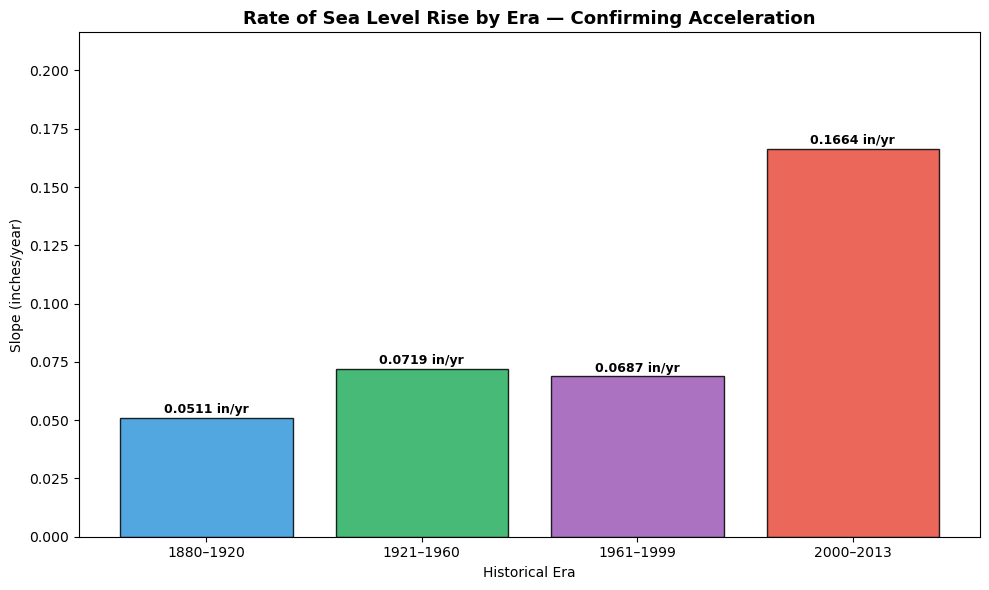

Full history slope : 0.0630 in/yr  (Model 1 baseline)
Post-2000 slope    : 0.1664 in/yr  (Model 2 baseline)
Acceleration factor: 2.64× faster since 2000


In [190]:
# Era-by-era rate of rise — bar chart quantifying acceleration
eras_def = [('1880–1920', 1880, 1920), ('1921–1960', 1921, 1960),
            ('1961–1999', 1961, 1999), ('2000–2013', 2000, 2013)]

era_names  = [e[0] for e in eras_def]
era_slopes = []
for _, start, end in eras_def:
    subset = df[(df['Year'] >= start) & (df['Year'] <= end)]
    era_slopes.append(linregress(subset['Year'], subset['CSIRO Adjusted Sea Level'])[0])

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['#3498db', '#27ae60', '#9b59b6', '#e74c3c']
bars = ax.bar(era_names, era_slopes, color=bar_colors, edgecolor='black', alpha=0.85)

for bar, val in zip(bars, era_slopes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0008,
            f'{val:.4f} in/yr', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Rate of Sea Level Rise by Era — Confirming Acceleration', fontsize=13, fontweight='bold')
ax.set_xlabel('Historical Era')
ax.set_ylabel('Slope (inches/year)')
ax.set_ylim(0, max(era_slopes) * 1.3)

plt.tight_layout()
plt.show()

s_all = linregress(df['Year'], df['CSIRO Adjusted Sea Level'])[0]
s_2k  = linregress(df[df['Year'] >= 2000]['Year'],
                   df[df['Year'] >= 2000]['CSIRO Adjusted Sea Level'])[0]
print(f"Full history slope : {s_all:.4f} in/yr  (Model 1 baseline)")
print(f"Post-2000 slope    : {s_2k:.4f} in/yr  (Model 2 baseline)")
print(f"Acceleration factor: {s_2k / s_all:.2f}× faster since 2000")

### 📐 6. Extended Linear Regression (sklearn)

We now apply **scikit-learn's `LinearRegression`** with an 80/20 train/test split to evaluate out-of-sample performance. Two models are fitted:

- **Model A** — full historical data (1880–2013), 134 rows → ~107 train / ~27 test points
- **Model B** — post-2000 data only (2000–2013), 14 rows → ~11 train / **~3 test points**

Evaluation metrics: **RMSE** (Root Mean Squared Error) and **MAE** (Mean Absolute Error).

> **⚠️ Data Practices Note:** A random 80/20 split is used here for simplicity. For time-series data this is technically a limitation — ideally a temporal split (train on earlier years, test on later years) would be used to prevent data leakage. Additionally, **Model B's test set contains only ~3 points**, so its RMSE/MAE should be interpreted with caution and not compared directly to Model A's metrics (different data ranges and sample sizes).

> The `Year_scaled` feature is computed using the **full-dataset** mean and standard deviation, ensuring consistent scaling across both models.

In [191]:
# ── Model A: Full history linear regression (sklearn) ──────────────────────
X_full = df[['Year_scaled']].values
y_full = df['CSIRO Adjusted Sea Level'].values

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

lr_A = LinearRegression()
lr_A.fit(X_train_A, y_train_A)
y_pred_A = lr_A.predict(X_test_A)

rmse_A = np.sqrt(mean_squared_error(y_test_A, y_pred_A))
mae_A  = mean_absolute_error(y_test_A, y_pred_A)
r2_A   = lr_A.score(X_test_A, y_test_A)

print("Model A — Full History Linear Regression (sklearn)")
print(f"  Train size : {len(X_train_A)}  |  Test size : {len(X_test_A)}")
print(f"  RMSE       : {rmse_A:.4f} inches")
print(f"  MAE        : {mae_A:.4f} inches")
print(f"  R²  (test) : {r2_A:.4f}")

# ── Model B: Post-2000 linear regression (sklearn) ─────────────────────────
df_2000 = df[df['Year'] >= 2000].copy()
X_2000  = df_2000[['Year_scaled']].values
y_2000  = df_2000['CSIRO Adjusted Sea Level'].values

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_2000, y_2000, test_size=0.2, random_state=42
)

lr_B = LinearRegression()
lr_B.fit(X_train_B, y_train_B)
y_pred_B = lr_B.predict(X_test_B)

rmse_B = np.sqrt(mean_squared_error(y_test_B, y_pred_B))
mae_B  = mean_absolute_error(y_test_B, y_pred_B)
r2_B   = lr_B.score(X_test_B, y_test_B)

print("\nModel B — Post-2000 Linear Regression (sklearn)")
print(f"  Train size : {len(X_train_B)}  |  Test size : {len(X_test_B)}")
print(f"  RMSE       : {rmse_B:.4f} inches")
print(f"  MAE        : {mae_B:.4f} inches")
print(f"  R²  (test) : {r2_B:.4f}")

Model A — Full History Linear Regression (sklearn)
  Train size : 107  |  Test size : 27
  RMSE       : 0.4068 inches
  MAE        : 0.3376 inches
  R²  (test) : 0.9651

Model B — Post-2000 Linear Regression (sklearn)
  Train size : 11  |  Test size : 3
  RMSE       : 0.0594 inches
  MAE        : 0.0470 inches
  R²  (test) : 0.9948


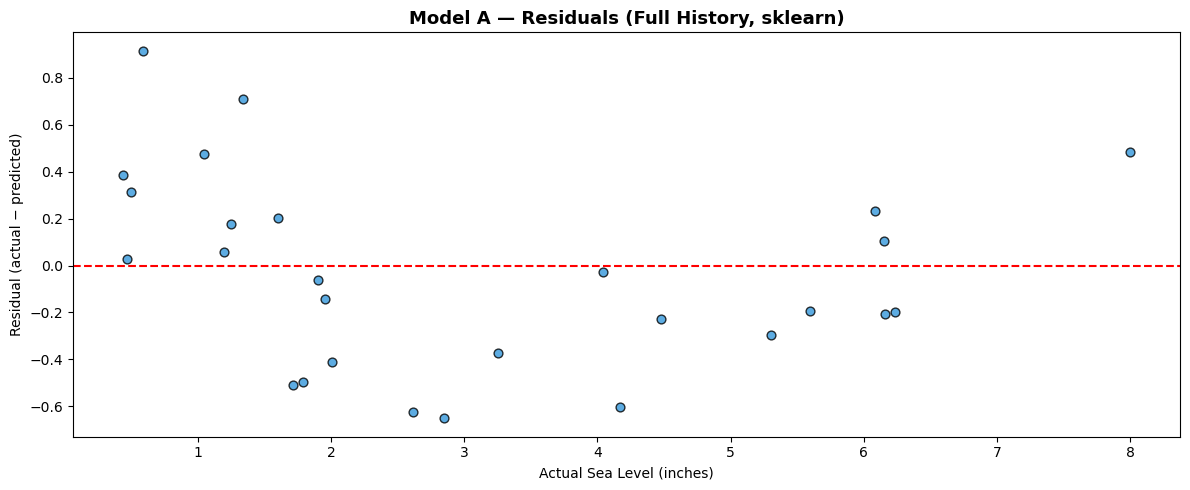

In [192]:
# Residual Plot — Model A (Full History)
fig, ax = plt.subplots(figsize=(12, 5))

ax.scatter(y_test_A, y_test_A - y_pred_A, color='#3498db', edgecolors='black', s=40, alpha=0.8)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Model A — Residuals (Full History, sklearn)', fontsize=13, fontweight='bold')
ax.set_xlabel('Actual Sea Level (inches)')
ax.set_ylabel('Residual (actual − predicted)')

plt.tight_layout()
plt.show()

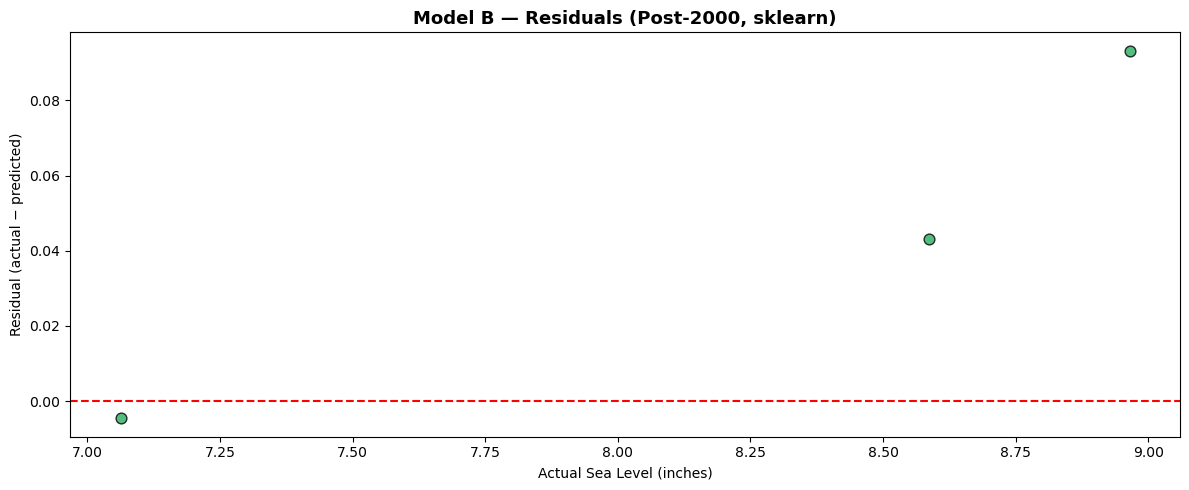

In [193]:
# Residual Plot — Model B (Post-2000)
fig, ax = plt.subplots(figsize=(12, 5))

ax.scatter(y_test_B, y_test_B - y_pred_B, color='#27ae60', edgecolors='black', s=60, alpha=0.8)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Model B — Residuals (Post-2000, sklearn)', fontsize=13, fontweight='bold')
ax.set_xlabel('Actual Sea Level (inches)')
ax.set_ylabel('Residual (actual − predicted)')

plt.tight_layout()
plt.show()

### 📉 7. Polynomial Regression

Linear models assume a constant rate of change. Polynomial regression allows the model to capture the **acceleration** in sea level rise by adding higher-order terms (Year², Year³).

We test **degree 2** and **degree 3** polynomials on the full dataset with an 80/20 train/test split.

Polynomial Degree 2
  RMSE       : 0.2273 inches
  MAE        : 0.1927 inches
  R²  (test) : 0.9891

Polynomial Degree 3
  RMSE       : 0.2489 inches
  MAE        : 0.1986 inches
  R²  (test) : 0.9869



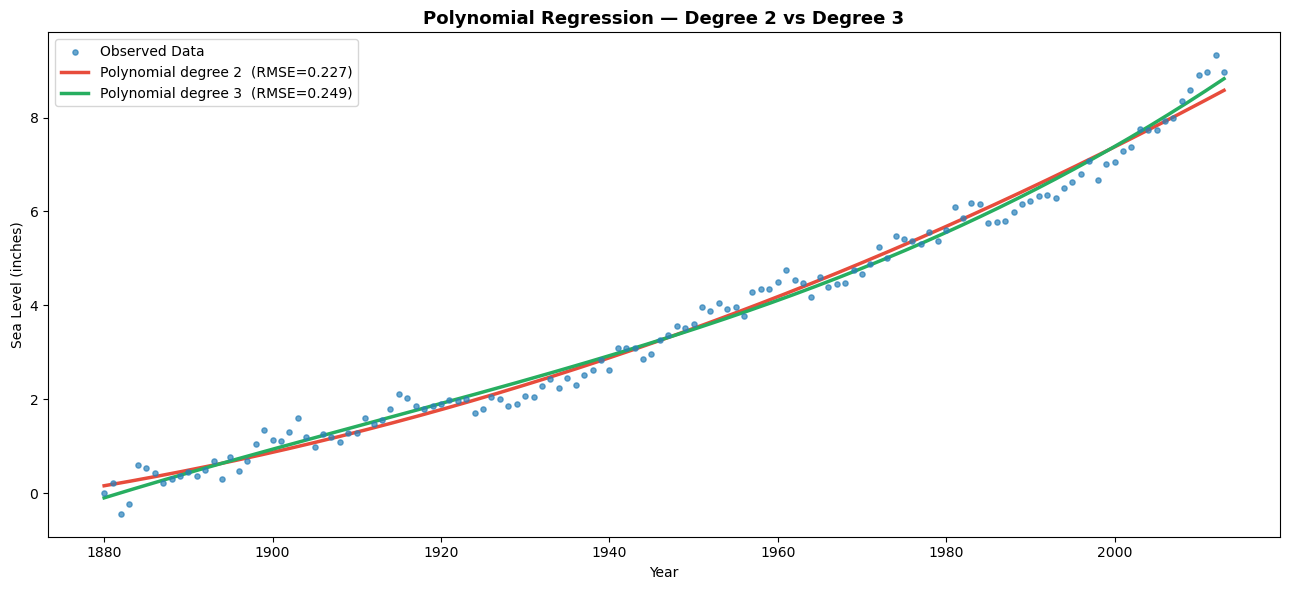

In [194]:
# ── Prepare features for polynomial regression ─────────────────────────────
X_base  = df[['Year_scaled']].values
y_base  = df['CSIRO Adjusted Sea Level'].values

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42
)

results_poly = {}

for degree in [2, 3]:
    poly    = PolynomialFeatures(degree=degree, include_bias=False)
    X_tr_p  = poly.fit_transform(X_train_p)
    X_te_p  = poly.transform(X_test_p)

    lr_poly = LinearRegression()
    lr_poly.fit(X_tr_p, y_train_p)
    y_pred_p = lr_poly.predict(X_te_p)

    rmse_p = np.sqrt(mean_squared_error(y_test_p, y_pred_p))
    mae_p  = mean_absolute_error(y_test_p, y_pred_p)
    r2_p   = lr_poly.score(X_te_p, y_test_p)
    results_poly[degree] = {'poly': poly, 'model': lr_poly, 'rmse': rmse_p, 'mae': mae_p, 'r2': r2_p}

    print(f"Polynomial Degree {degree}")
    print(f"  RMSE       : {rmse_p:.4f} inches")
    print(f"  MAE        : {mae_p:.4f} inches")
    print(f"  R²  (test) : {r2_p:.4f}\n")

rmse_poly2 = results_poly[2]['rmse']
rmse_poly3 = results_poly[3]['rmse']
mae_poly2  = results_poly[2]['mae']
mae_poly3  = results_poly[3]['mae']

# ── Visual comparison: degree-2 vs degree-3 fit ────────────────────────────
years_plot   = np.linspace(df['Year'].min(), df['Year'].max(), 300)
years_scaled = ((years_plot - year_mean) / year_std).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(13, 6))
ax.scatter(df['Year'], df['CSIRO Adjusted Sea Level'],
           color='#2980b9', s=14, alpha=0.7, zorder=3, label='Observed Data')

for deg, color in [(2, '#e74c3c'), (3, '#27ae60')]:
    info  = results_poly[deg]
    X_vis = info['poly'].transform(years_scaled)
    y_vis = info['model'].predict(X_vis)
    ax.plot(years_plot, y_vis, color=color, linewidth=2.5,
            label=f'Polynomial degree {deg}  (RMSE={info["rmse"]:.3f})')

ax.set_title('Polynomial Regression — Degree 2 vs Degree 3', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Sea Level (inches)')
ax.legend()
plt.tight_layout()
plt.show()

### 🌳 8. Decision Tree Regressor

Decision trees divide the feature space into rectangular subsets and predict the mean value in each leaf. They can capture **step-wise non-linear patterns** without assuming a functional form.

- **Feature:** `Year_scaled`
- **Target:** `CSIRO Adjusted Sea Level`
- **Max depth:** 5 (to prevent severe overfitting)
- **Split:** 80% train / 20% test

> Decision trees **do not extrapolate** beyond the training range — they return the last leaf's value for any future year outside the training data. This makes them unsuitable for 2050 prediction but useful for understanding patterns within the historical range.

Decision Tree Regressor (max_depth=5)
  Train size : 107  |  Test size : 27
  RMSE       : 0.2814 inches
  MAE        : 0.2122 inches
  R²  (test) : 0.9833

  Note: max_depth=5 limits tree depth to reduce overfitting.
  Decision trees cannot extrapolate beyond the training range (1880–2013).
  The visualization below shows the step-wise fit within the historical period only.


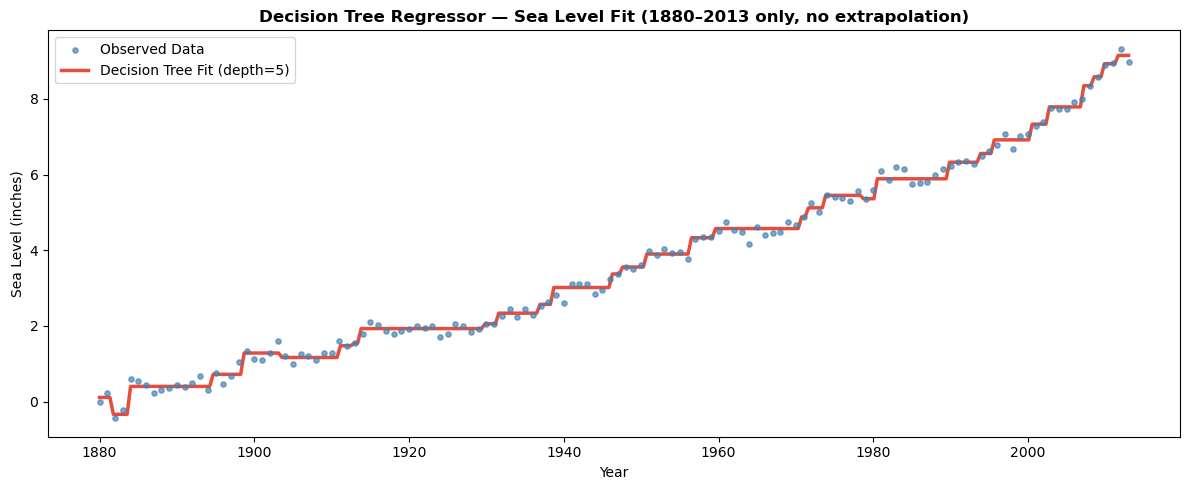

In [195]:
# ── Decision Tree Regressor (full dataset, 80/20 split) ────────────────────
X_dt     = df[['Year_scaled']].values
y_dt     = df['CSIRO Adjusted Sea Level'].values

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y_dt, test_size=0.2, random_state=42
)

dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_reg.fit(X_train_dt, y_train_dt)
y_pred_dt = dt_reg.predict(X_test_dt)

rmse_dt = np.sqrt(mean_squared_error(y_test_dt, y_pred_dt))
mae_dt  = mean_absolute_error(y_test_dt, y_pred_dt)
r2_dt   = dt_reg.score(X_test_dt, y_test_dt)

print("Decision Tree Regressor (max_depth=5)")
print(f"  Train size : {len(X_train_dt)}  |  Test size : {len(X_test_dt)}")
print(f"  RMSE       : {rmse_dt:.4f} inches")
print(f"  MAE        : {mae_dt:.4f} inches")
print(f"  R²  (test) : {r2_dt:.4f}")
print()
print("  Note: max_depth=5 limits tree depth to reduce overfitting.")
print("  Decision trees cannot extrapolate beyond the training range (1880–2013).")
print("  The visualization below shows the step-wise fit within the historical period only.")

# ── Visualize DT fit vs actual (historical range only — DT cannot extrapolate to 2050) ──
years_dt_plot   = np.linspace(df['Year'].min(), df['Year'].max(), 300)
years_dt_scaled = ((years_dt_plot - year_mean) / year_std).reshape(-1, 1)
dt_curve        = dt_reg.predict(years_dt_scaled)

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(df['Year'], df['CSIRO Adjusted Sea Level'],
           color='steelblue', s=14, alpha=0.7, label='Observed Data', zorder=3)
ax.plot(years_dt_plot, dt_curve, color='#e74c3c', linewidth=2.5, label='Decision Tree Fit (depth=5)')
ax.set_title('Decision Tree Regressor — Sea Level Fit (1880–2013 only, no extrapolation)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Sea Level (inches)')
ax.legend()
plt.tight_layout()
plt.show()

### 📊 9. Model Evaluation & Comparison

We compare all models side-by-side using **RMSE** and **MAE** on their respective test sets. This shows which approach best generalizes to unseen data — critical for reliable extrapolation to 2050.

> **Lower RMSE/MAE = better generalization.**
> Linear models trained on longer time spans generally extrapolate more reliably than decision trees or high-degree polynomials.

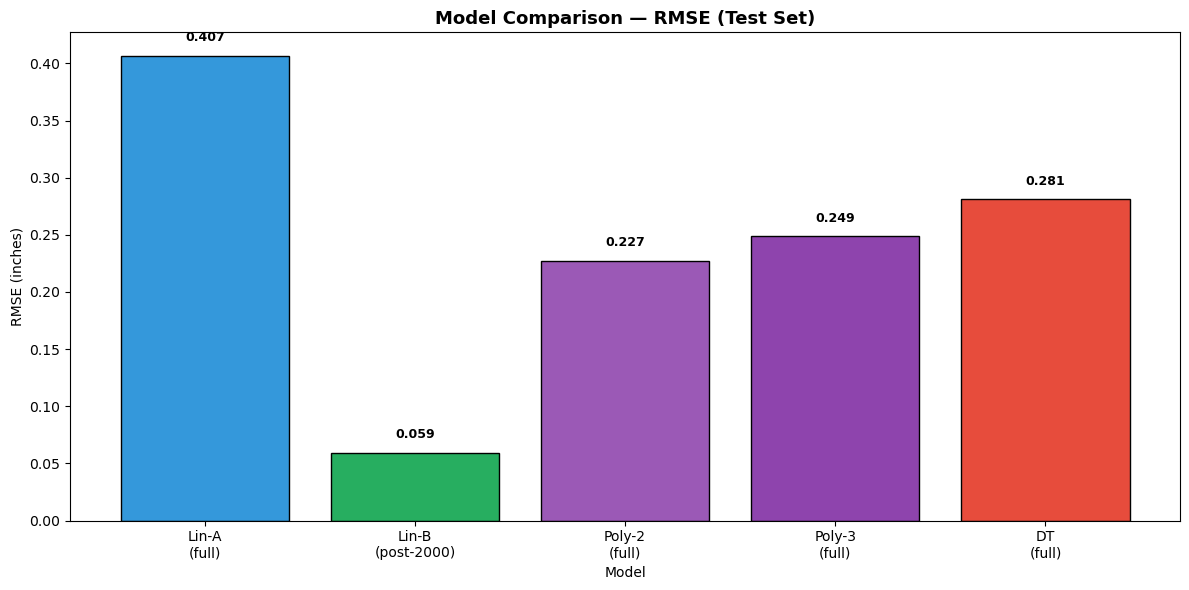

In [196]:
models    = ['Lin-A\n(full)', 'Lin-B\n(post-2000)', 'Poly-2\n(full)', 'Poly-3\n(full)', 'DT\n(full)']
rmse_vals = [rmse_A, rmse_B, rmse_poly2, rmse_poly3, rmse_dt]
mae_vals  = [mae_A,  mae_B,  mae_poly2,  mae_poly3,  mae_dt]
palette   = ['#3498db', '#27ae60', '#9b59b6', '#8e44ad', '#e74c3c']

# ── RMSE Comparison Bar Chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(models, rmse_vals, color=palette, edgecolor='black')
ax.set_title('Model Comparison — RMSE (Test Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE (inches)')
ax.set_xlabel('Model')
for bar, val in zip(bars1, rmse_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

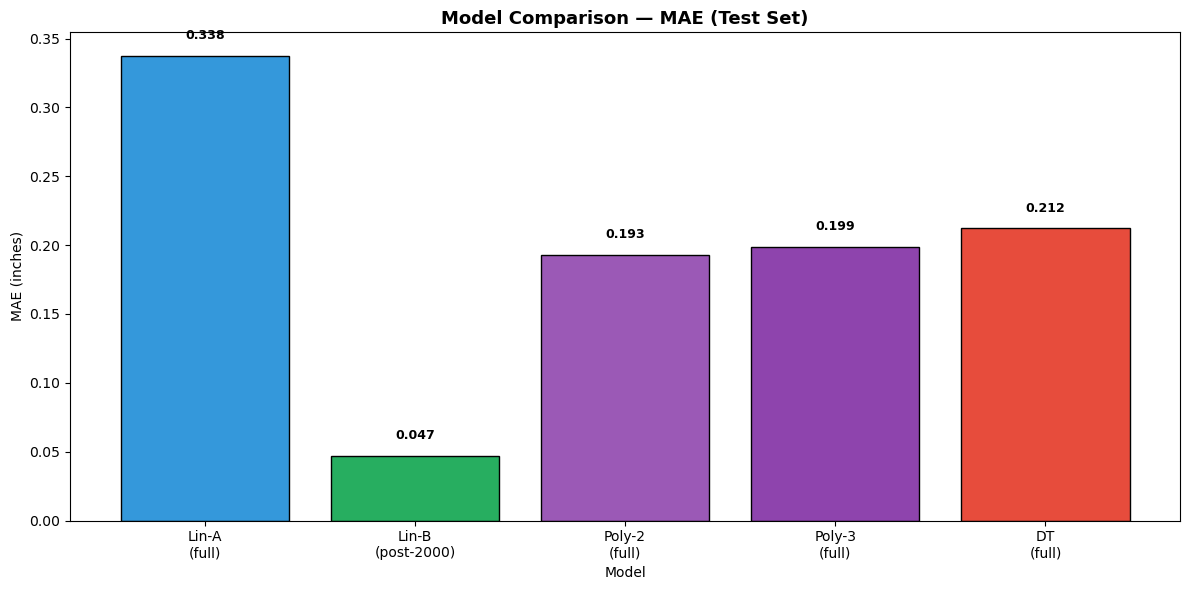


Model                         RMSE      MAE
─────────────────────────────────────────────
  Lin-A (full)              0.4068   0.3376
  Lin-B (post-2000)         0.0594   0.0470
  Poly-2 (full)             0.2273   0.1927
  Poly-3 (full)             0.2489   0.1986
  DT (full)                 0.2814   0.2122

  Best RMSE → Lin-B (post-2000)


In [197]:
# ── MAE Comparison Bar Chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

bars2 = ax.bar(models, mae_vals, color=palette, edgecolor='black')
ax.set_title('Model Comparison — MAE (Test Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('MAE (inches)')
ax.set_xlabel('Model')
for bar, val in zip(bars2, mae_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Comparison Table ─────────────────────────────────────────────────────────
print(f"\n{'Model':<25} {'RMSE':>8} {'MAE':>8}")
print("─" * 45)
for m, r, a in zip(models, rmse_vals, mae_vals):
    label = m.replace('\n', ' ')
    print(f"  {label:<23} {r:>8.4f} {a:>8.4f}")
best_model = models[rmse_vals.index(min(rmse_vals))].replace('\n', ' ')
print(f"\n  Best RMSE → {best_model}")

### 📋 10. Summary & Milestone Predictions

Final summary of all model results, rate comparisons, and projected sea level values at key future milestones under both the long-term historical and modern acceleration scenarios.

In [198]:
total_rise    = df['CSIRO Adjusted Sea Level'].max() - df['CSIRO Adjusted Sea Level'].min()
first_year    = int(df['Year'].min())
last_year     = int(df['Year'].max())
years_span    = last_year - first_year

# scipy baselines for summary
s1, i1, r1 = linregress(df['Year'], df['CSIRO Adjusted Sea Level'])[:3]
s2_df       = df[df['Year'] >= 2000]
s2, i2, r2  = linregress(s2_df['Year'], s2_df['CSIRO Adjusted Sea Level'])[:3]

pred1_2050 = s1 * 2050 + i1
pred2_2050 = s2 * 2050 + i2

# ── OLS 95% CI helper — reuses t_dist from imports (Cell 2) ─────────────
def _ols_ci(x_data, y_data, slope, intercept, x_pred, alpha=0.05):
    """Return half-width of the OLS prediction mean CI at x_pred."""
    n    = len(x_data)
    xbar = x_data.mean()
    Sxx  = np.sum((x_data - xbar) ** 2)
    s_e  = np.sqrt(np.sum((y_data - (slope * x_data + intercept)) ** 2) / (n - 2))
    t_c  = t_dist.ppf(1 - alpha / 2, df=n - 2)
    return t_c * s_e * np.sqrt(1 / n + (x_pred - xbar) ** 2 / Sxx)

x1_a = df['Year'].values
y1_a = df['CSIRO Adjusted Sea Level'].values
x2_a = s2_df['Year'].values
y2_a = s2_df['CSIRO Adjusted Sea Level'].values

ci1_at_2050 = _ols_ci(x1_a, y1_a, s1, i1, 2050)
ci2_at_2050 = _ols_ci(x2_a, y2_a, s2, i2, 2050)

print("=" * 70)
print("            SEA LEVEL PREDICTOR — FINAL SUMMARY")
print("=" * 70)
print(f"  Dataset period              : {first_year} → {last_year}")
print(f"  Total observed rise         : {total_rise:.2f} inches over {years_span} years")
print(f"  Avg rise (observed)         : {total_rise/years_span:.4f} inches/year")
print()
print(f"  ── Baseline Regression (scipy.stats.linregress) ──")
print(f"  Model 1 slope (1880–present): {s1:.6f} inches/year  (R²={r1**2:.4f})")
print(f"  Model 2 slope (2000–present): {s2:.6f} inches/year  (R²={r2**2:.4f})")
print(f"  Acceleration factor          : {s2/s1:.2f}× faster since 2000")
print()
print(f"  ── 2050 Predictions (with 95% OLS Confidence Intervals) ──")
print(f"  Model 1 (full history) : {pred1_2050:.2f} ± {ci1_at_2050:.2f} in"
      f"  →  [{pred1_2050-ci1_at_2050:.2f}, {pred1_2050+ci1_at_2050:.2f}]")
print(f"  Model 2 (since 2000)   : {pred2_2050:.2f} ± {ci2_at_2050:.2f} in"
      f"  →  [{pred2_2050-ci2_at_2050:.2f}, {pred2_2050+ci2_at_2050:.2f}]")
print(f"  Difference (central)   : {pred2_2050 - pred1_2050:+.2f} inches")
print(f"  ⚠  Model 2 CI is wider — fit on only {len(x2_a)} years (2000–2013)")
print()

milestones = [2025, 2030, 2040, 2050]
print(f"  ── Milestone Projections (inches above 1880 baseline) ──")
print(f"  {'Year':<6} {'Model 1':>10} {'95% CI M1':>16} {'Model 2':>10} {'95% CI M2':>18}")
print(f"  {'-'*64}")
for yr in milestones:
    p1 = s1 * yr + i1
    p2 = s2 * yr + i2
    ci1_yr = _ols_ci(x1_a, y1_a, s1, i1, yr)
    ci2_yr = _ols_ci(x2_a, y2_a, s2, i2, yr)
    print(f"  {yr:<6} {p1:>10.3f}   [{p1-ci1_yr:.2f}, {p1+ci1_yr:.2f}]"
          f"   {p2:>10.3f}   [{p2-ci2_yr:.2f}, {p2+ci2_yr:.2f}]")

print()
print("  ⚠  All values beyond 2013 are scenario-based projections.")
print("  ⚠  CI bands assume a constant linear rate — real-world rates may change.")
print("=" * 70)

            SEA LEVEL PREDICTOR — FINAL SUMMARY
  Dataset period              : 1880 → 2013
  Total observed rise         : 9.77 inches over 133 years
  Avg rise (observed)         : 0.0734 inches/year

  ── Baseline Regression (scipy.stats.linregress) ──
  Model 1 slope (1880–present): 0.063045 inches/year  (R²=0.9697)
  Model 2 slope (2000–present): 0.166427 inches/year  (R²=0.9531)
  Acceleration factor          : 2.64× faster since 2000

  ── 2050 Predictions (with 95% OLS Confidence Intervals) ──
  Model 1 (full history) : 10.18 ± 0.21 in  →  [9.96, 10.39]
  Model 2 (since 2000)   : 15.38 ± 1.01 in  →  [14.37, 16.40]
  Difference (central)   : +5.21 inches
  ⚠  Model 2 CI is wider — fit on only 14 years (2000–2013)

  ── Milestone Projections (inches above 1880 baseline) ──
  Year      Model 1        95% CI M1    Model 2          95% CI M2
  ----------------------------------------------------------------
  2025        8.599   [8.43, 8.77]       11.222   [10.78, 11.66]
  2030     